In [1]:
%load_ext autoreload
%autoreload 2
import torch
from torch import nn
from Systems import Kuramoto
import numpy as np
from NN import Main_Network, NN
import matplotlib.pyplot as plt
from Dataset import DataSet
from Normalizer import Normalizer
from Trainer import Trainer
import scipy.io as spio
from Observer import System_z, Observer
import torch.nn.functional as F

In [2]:
#------------- Kuramoto ------------- 
coupling = 3

A = np.array([[0.82609078, 0.766099  , 0.04770744, 0.95634223, 0.48535484, 0.82770635, 0.82568269, 0.41482854, 0.10805105, 0.84533148],
                [0.16793279, 0.52216174, 0.32375506, 0.21255903, 0.74318917, 0.27801737, 0.62963795, 0.46563399, 0.87285444, 0.44818149],
                [0.85739688, 0.35466085, 0.23081837, 0.77816442, 0.44434047, 0.04087587, 0.96132654, 0.20077639, 0.35555799, 0.5465003 ],
                [0.66843566, 0.63740146, 0.92209938, 0.83202012, 0.11184414, 0.60635776, 0.70997797, 0.85543721, 0.97555328, 0.59325376],
                [0.35215001, 0.01401137, 0.49319654, 0.17891016, 0.0477552 , 0.85102004, 0.95226833, 0.60082744, 0.80278956, 0.56294354],
                [0.63712071, 0.12634065, 0.71471804, 0.4522626 , 0.82374189, 0.42226771, 0.71647475, 0.70623256, 0.66294877, 0.40769281],
                [0.485451  , 0.7179554 , 0.00683135, 0.76084085, 0.71155059, 0.65390833, 0.55031198, 0.94644044, 0.84509827, 0.29303649],
                [0.00997047, 0.7187184 , 0.84228867, 0.07802682, 0.2649064 , 0.72994764, 0.94594025, 0.50939704, 0.78263394, 0.3596041 ],
                [0.95868957, 0.89330904, 0.36732745, 0.41224862, 0.23902724, 0.81451302, 0.06999864, 0.49742364, 0.40118135, 0.23091774],
                [0.64234836, 0.89619788, 0.0335701 , 0.41857516, 0.19653272,0.63108802, 0.47687404, 0.89418281, 0.26760051, 0.58927806]])

a = np.ones([21,1])
b = np.eye(5)
K = np.kron(a,b)
a = np.diag(np.linspace(15, 20, 21))
M = -np.kron(a,b)

a = 0
b = 31
N = 1000
limits = np.array([[-2, 2], [-2, 2], [-2, 2],[-2, 2], [-2, 2], [-2, 2],[-2, 2], [-2, 2], [-2, 2],[-2, 2]])    # Sample space for normal datapoints
num_ic = 50       # Number of initial conditions to be sampled
kuramoto = Kuramoto(10, coupling, adj_mat = A)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


model_data = torch.load('models/kuramoto_T_inverse_lr0.0001_batch32_epoch10')
num_hidden = model_data['config']['num_hidden']
hidden_size = model_data['config']['hidden_size']
x_size = model_data['config']['x_size']
z_size = model_data['config']['z_size']
activation = model_data['config']['activation']
normalizer = model_data['config']['normalizer']
T_inv_net = NN(num_hidden, hidden_size, z_size, x_size, activation, normalizer=normalizer).to(device)
T_inv_net.load_state_dict(model_data['model'])
T_inv_net.eval()

observer2 = Observer(kuramoto, M, K, T_inv_net, a, b, N, init_z_zero=True)

initial_conds = np.arange(0.1, 5.1, 0.1)
MAE_x_list_new = []
MAE_y_list_new = []

# for ic in initial_conds:
#     ic = np.ones([1,10])*ic
#     x, x_hat, t, error = observer2.simulate(ic, add_noise = False)
#     MAE_x = np.mean(error[0][:,0])
#     MAE_y = np.mean(error[0][:,1])
#     MAE_x_list_new.append(MAE_x)
#     MAE_y_list_new.append(MAE_y)

# fig = plt.figure(figsize = (8,8), facecolor='w')
# plt.plot(initial_conds, MAE_x_list_new, label = 'MAE x')
# plt.plot(initial_conds, MAE_y_list_new, label = 'MAE y')
# plt.legend()
# plt.title('New Method')
# plt.xlabel('Initial (x0,y0)')
# plt.ylabel('Mean Absolute Error')
# plt.show()

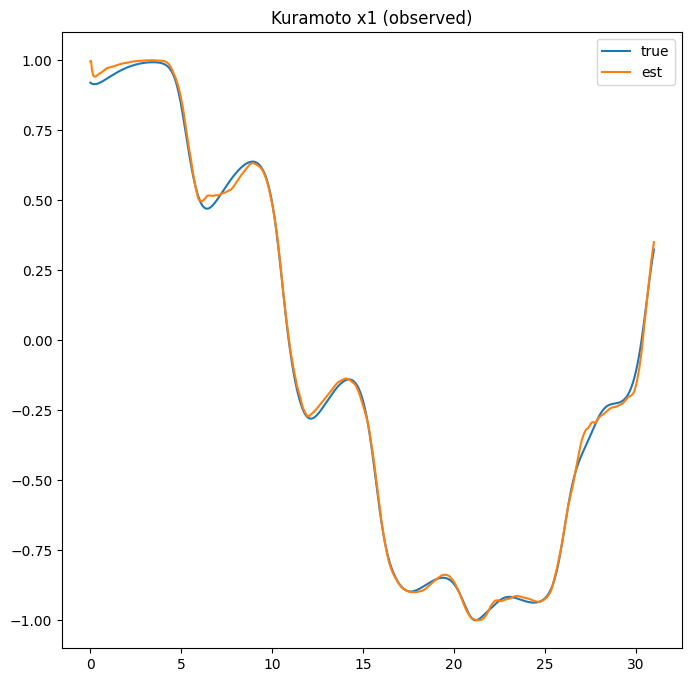

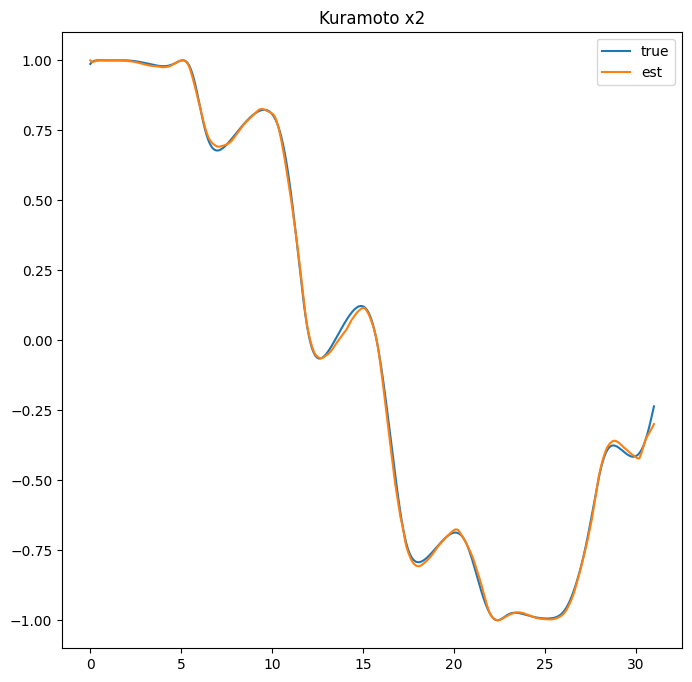

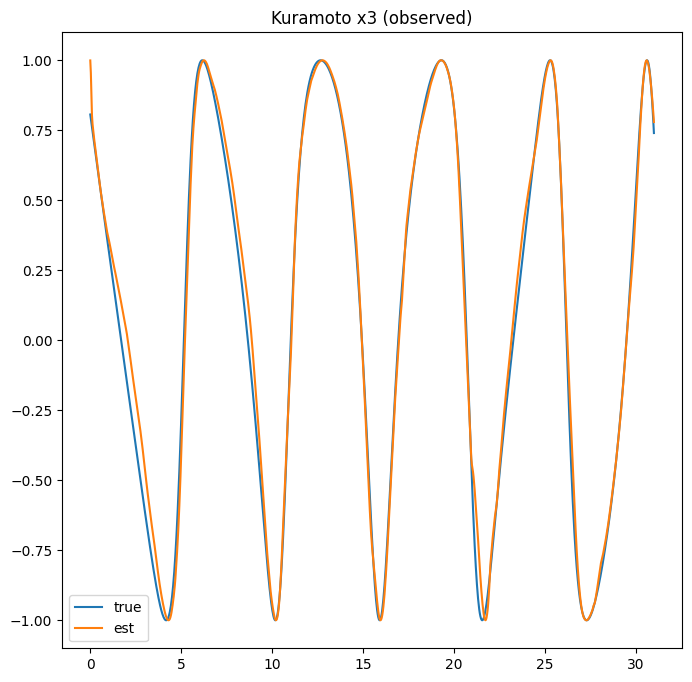

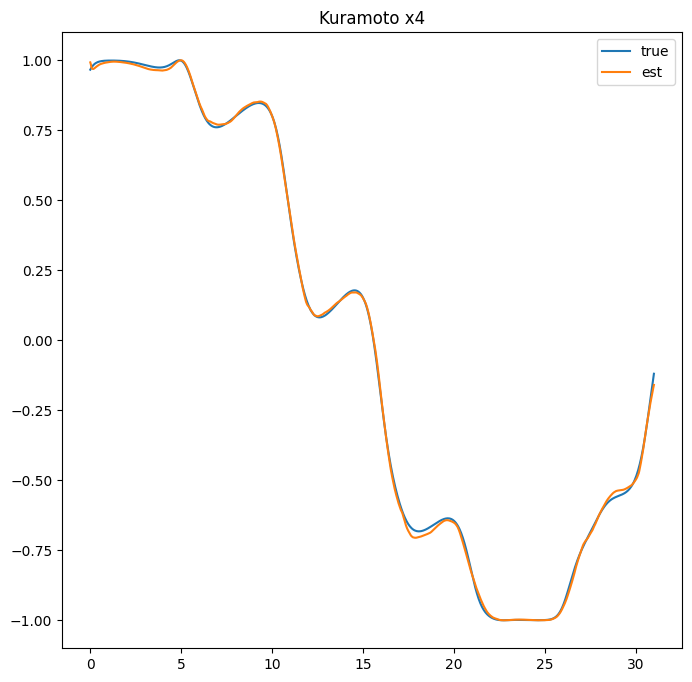

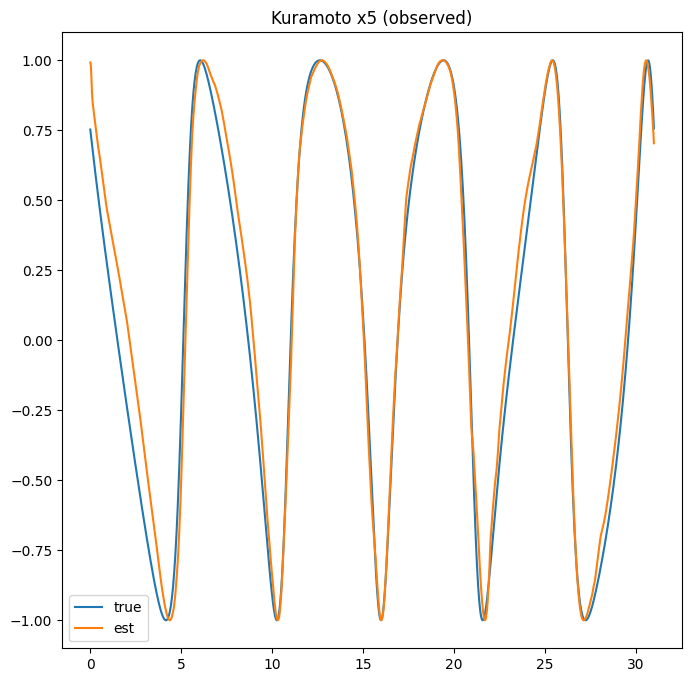

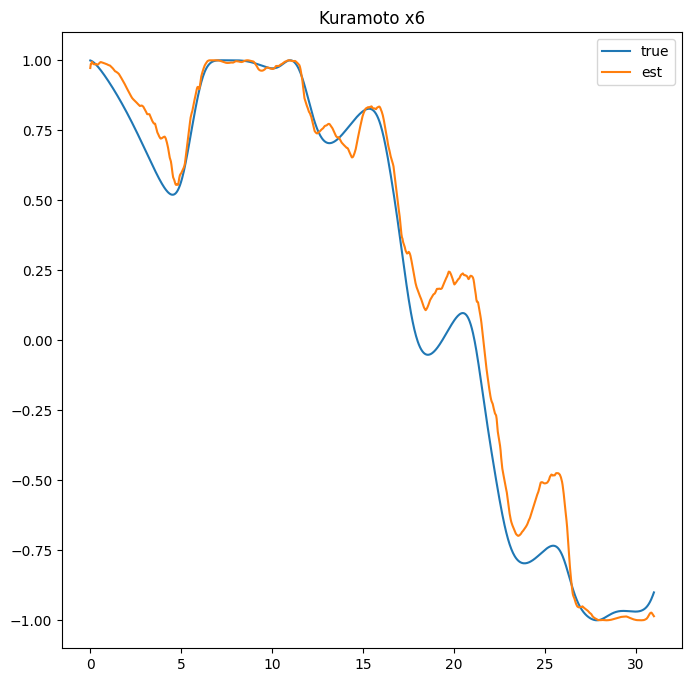

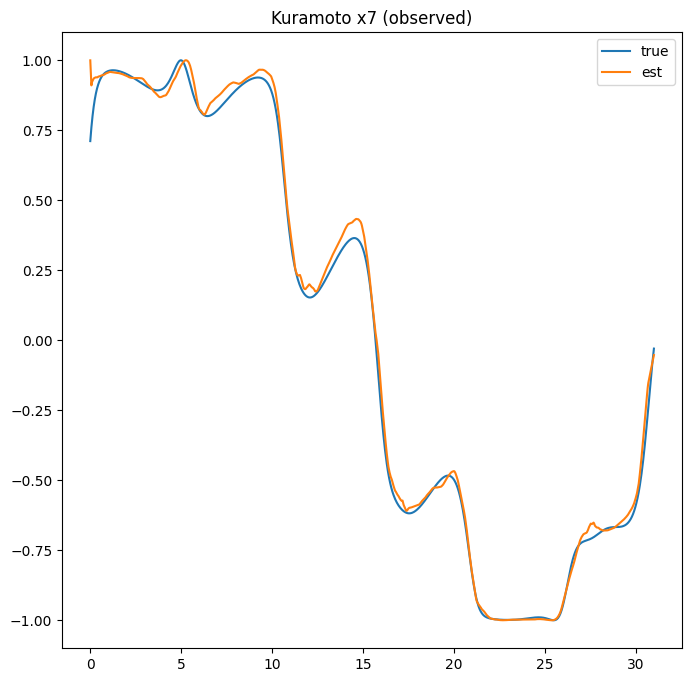

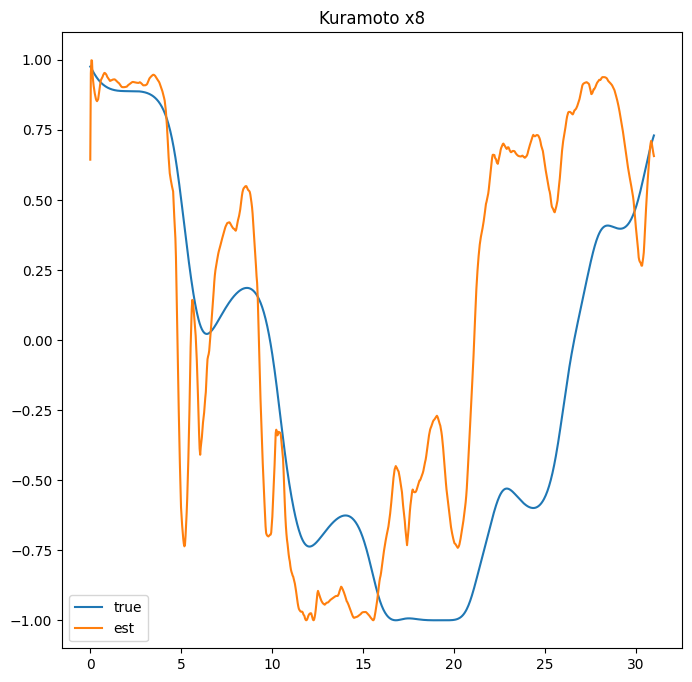

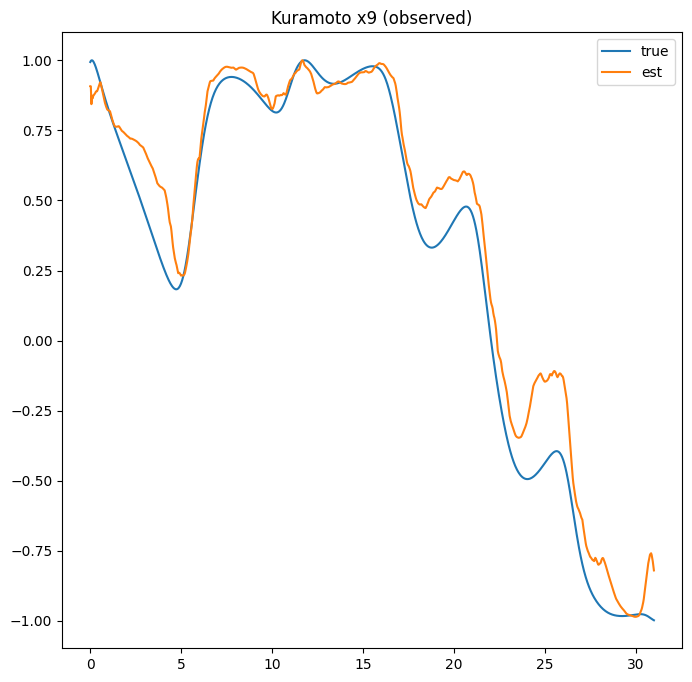

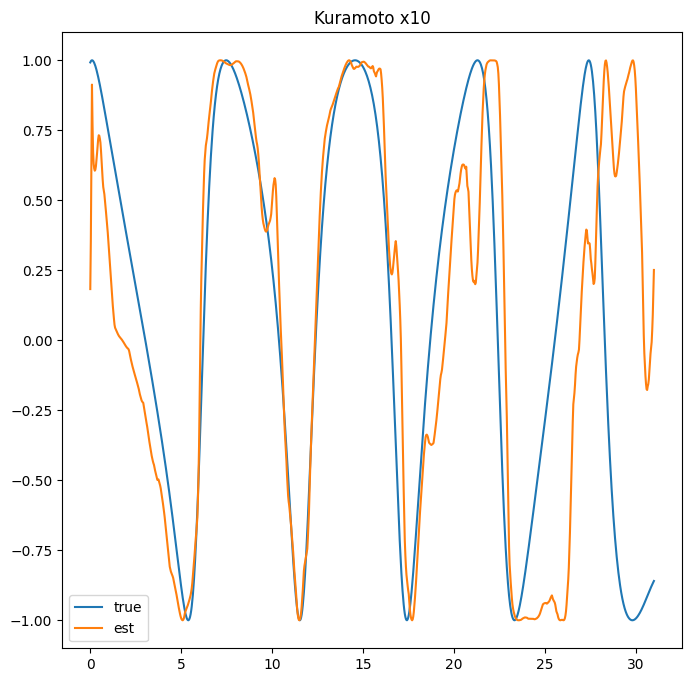

In [3]:
ic = np.random.uniform(-1,1,[1,10])

x, x_hat, t, error = observer2.simulate(ic, add_noise = False)

for i in range(10):
    fig = plt.figure(figsize = (8,8), facecolor='w')
    plt.plot(t, np.cos(x[:,i]), label = 'true')
    plt.plot(t, np.cos(x_hat[:,i]), label = 'est')
    if i % 2 == 0:
        plt.title(f'Kuramoto x{i+1} (observed)')
    else:
        plt.title(f'Kuramoto x{i+1}')
    plt.legend()
    plt.show()

